In [28]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path

# ========== 从 batch_metrics YAML 加载结果路径 ==========
# notebook 位于 figures/PCA101A/，TSFM 根目录在两级之上
TSFM_ROOT = Path('../..')
cfg_path = TSFM_ROOT / 'setting' / 'batch_metrics_pca101a.yaml'
cfg = yaml.safe_load(cfg_path.read_text())
params = cfg.get('params', {})

seq_len = params['seq_len']       # 1440
pred_len = params['pred_len']     # 96
eval_steps = params.get('eval_steps', pred_len)  # 15
target = params['target']
results_root = TSFM_ROOT / params.get('results_root', './results')

model_dirs = {entry['name']: entry['result_dir'] for entry in cfg['model_dirs']}

def load_pred(name):
    p = results_root / model_dirs[name] / 'pred.npy'
    if not p.exists():
        print(f'WARNING: {p} not found')
        return None
    arr = np.load(p)
    if arr.ndim == 3:
        arr = arr[:, :, -1]  # target column
    return arr[:, :eval_steps]  # truncate to eval_steps

def load_true(name):
    p = results_root / model_dirs[name] / 'true.npy'
    if not p.exists():
        print(f'WARNING: {p} not found')
        return None
    arr = np.load(p)
    if arr.ndim == 3:
        arr = arr[:, :, -1]
    return arr[:, :eval_steps]

# ========== 加载数据 ==========
plot_true = load_true('Partial15-U')
plot_pred = load_pred('Partial15-U')

pred_zeroshot_u = load_pred('Zeroshot-U')
pred_zeroshot_m = load_pred('Zeroshot-M')
pred_zeroshot_co = load_pred('Zeroshot-Co')
pred_finetuned_u = load_pred('Finetuned-U')
pred_finetuned_co = load_pred('Finetuned-Co')
pred_partial15_u = load_pred('Partial15-U')
pred_partial15_co = load_pred('Partial15-Co')

print(f'seq_len={seq_len}  pred_len={pred_len}  eval_steps={eval_steps}')
print(f'plot_true shape: {plot_true.shape if plot_true is not None else "N/A"}')
print(f'plot_pred shape: {plot_pred.shape if plot_pred is not None else "N/A"}')

seq_len=1536  pred_len=96  eval_steps=15
plot_true shape: (193369, 15)
plot_pred shape: (193369, 15)


#### PCA101A On GTProger 的结果，要对其 Timer-XL 预训练时候的 $Lookback = 1440$ 和 $Forecasting = 96$

In [29]:
import numpy as np
import pandas as pd
import yaml
from pathlib import Path

# ========== 从 splits.yaml 自动构建结果路径 ==========
# notebook 位于 TSFM/figures/PCA101A/，MyTimeXer 根目录在三级之上再进入 MyTimeXer
MYTIMEXER_ROOT = Path('../../..') / 'MyTimeXer'
split_file = MYTIMEXER_ROOT / 'scripts' / 'forecast_exogenous' / 'JJ_PCA101A' / 'splits.yaml'
cfg_mtx = yaml.safe_load(split_file.read_text())
params_mtx = cfg_mtx.get('params', {})

mtx_seq_len   = params_mtx['seq_len']       # 30
mtx_label_len = params_mtx['label_len']      # 30
mtx_pred_len  = params_mtx['pred_len']       # 15
mtx_target    = params_mtx['target']
mtx_dataset_id = params_mtx['dataset_id']
d_model_map   = params_mtx.get('batch_model_d_model', {})
d_ff_map      = params_mtx.get('batch_model_d_ff', {})
e_layers_map  = params_mtx.get('batch_model_e_layers', {})
feature_map   = params_mtx.get('batch_model_features', {})

results_root_mtx = MYTIMEXER_ROOT / 'results'

def _build_result_dir(model_name):
    """Build result dir path from splits.yaml params."""
    features = feature_map.get(model_name, 'MS')
    model_arg = model_name
    des = f'{model_name}-MS'
    if model_name.lower() == 'timexer':
        model_arg = 'TimeXer'
        des = 'Timexer-MS'
    if features == 'M':
        des = des.replace('-MS', '-M')

    template = params_mtx.get('model_id_template', 'auto_{seq_len}_{label_len}_{pred_len}')
    model_id = template.format(seq_len=mtx_seq_len, label_len=mtx_label_len, pred_len=mtx_pred_len)

    setting = 'long_term_forecast_{}_{}_{}_ft{}_sl{}_ll{}_pl{}_dm{}_nh{}_el{}_dl{}_df{}_expand{}_dc{}_fc{}_eb{}_dt{}_{}_0'.format(
        model_id, model_arg, 'custom', features,
        mtx_seq_len, mtx_label_len, mtx_pred_len,
        d_model_map.get(model_name, params_mtx.get('d_model', 512)),
        params_mtx.get('n_heads', 8),
        e_layers_map.get(model_name, params_mtx.get('e_layers', 1)),
        params_mtx.get('d_layers', 1),
        d_ff_map.get(model_name, params_mtx.get('d_ff', 2048)),
        params_mtx.get('expand', 2),
        params_mtx.get('d_conv', 4),
        params_mtx.get('factor', 3),
        params_mtx.get('embed', 'timeF'),
        params_mtx.get('distil', True),
        des,
    )
    tags = [f'ds{mtx_dataset_id}', f't{mtx_target}']
    setting_tag = params_mtx.get('setting_tag', '')
    if setting_tag:
        tags.append(setting_tag)
    setting = setting + '_' + '_'.join(tags)
    return results_root_mtx / setting

def load_pred_mytimexer(model_name):
    d = _build_result_dir(model_name)
    p = d / 'pred.npy'
    if not p.exists():
        print(f'WARNING: {p} not found')
        return None
    return np.load(p)[:, :, -1]

def load_true_mytimexer(model_name):
    d = _build_result_dir(model_name)
    p = d / 'true.npy'
    if not p.exists():
        print(f'WARNING: {p} not found')
        return None
    return np.load(p)[:, :, -1]

# ========== 加载原始数据 ==========
plot_true_gtp_raw = load_true_mytimexer('GTProger')
plot_pred_gtp_raw = load_pred_mytimexer('GTProger')

pred_cnnlstm_raw      = load_pred_mytimexer('CNNLSTM')
pred_dipcalstm_raw    = load_pred_mytimexer('DiPCALSTM')
pred_tcn_raw          = load_pred_mytimexer('TCNTransformer')
pred_lstmgru_raw      = load_pred_mytimexer('LSTMGRU')
pred_STAConvBiLSTM_raw = load_pred_mytimexer('STAConvBiLSTM')
pred_timexer_raw      = load_pred_mytimexer('TimeXer')
pred_lightmoe_raw     = load_pred_mytimexer('TimeXerLightMoE')
pred_gtprogerv10_raw  = load_pred_mytimexer('GTProgerV10')
pred_gtprogerv11_raw  = load_pred_mytimexer('GTProgerV11')
pred_gtprogerv13_raw  = load_pred_mytimexer('GTProgerV13')

# ========== 对齐 MyTimeXer 索引与 TSFM 索引 ==========
# TSFM  window j: 预测起始位置 = j + seq_len(1440)
# MyTimeXer window i: 预测起始位置 = i + mtx_seq_len(30)
# 同一位置: j + 1440 = i + 30  =>  i = j + 1410
# 尾部差异: TSFM pred_len=96 占用更多未来数据，所以比 MyTimeXer 少 (96-15)=81 个窗口
#
# 对齐方法: mtx_aligned[j] = mtx_raw[j + offset],  j = 0..N_tsfm-1
offset = seq_len - mtx_seq_len   # 1440 - 30 = 1410  (seq_len from Cell 0)
N_tsfm = plot_true.shape[0]      # 193369  (plot_true from Cell 0)

def _align(arr):
    if arr is None:
        return None
    return arr[offset : offset + N_tsfm]

plot_true_gtp = _align(plot_true_gtp_raw)
plot_pred_gtp = _align(plot_pred_gtp_raw)

pred_cnnlstm       = _align(pred_cnnlstm_raw)
pred_dipcalstm     = _align(pred_dipcalstm_raw)
pred_tcn           = _align(pred_tcn_raw)
pred_lstmgru       = _align(pred_lstmgru_raw)
pred_STAConvBiLSTM = _align(pred_STAConvBiLSTM_raw)
pred_timexer       = _align(pred_timexer_raw)
pred_lightmoe      = _align(pred_lightmoe_raw)
pred_gtprogerv10   = _align(pred_gtprogerv10_raw)
pred_gtprogerv11   = _align(pred_gtprogerv11_raw)
pred_gtprogerv13   = _align(pred_gtprogerv13_raw)

# 验证对齐
assert plot_true_gtp.shape[0] == N_tsfm, f'Alignment failed: {plot_true_gtp.shape[0]} != {N_tsfm}'
assert np.allclose(plot_true_gtp[0], plot_true[0], atol=1e-4), 'True values mismatch at index 0'
assert np.allclose(plot_true_gtp[-1], plot_true[-1], atol=1e-4), 'True values mismatch at last index'

print(f'Alignment: offset={offset}, N_tsfm={N_tsfm}')
print(f'plot_true_gtp shape (aligned): {plot_true_gtp.shape}')
print(f'plot_pred_gtp shape (aligned): {plot_pred_gtp.shape}')
print(f'plot_true     shape (TSFM):    {plot_true.shape}')

Alignment: offset=1506, N_tsfm=193369
plot_true_gtp shape (aligned): (193369, 15)
plot_pred_gtp shape (aligned): (193369, 15)
plot_true     shape (TSFM):    (193369, 15)


In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def build_true45_from_patches(plot_true, idx, seq_len=30, pred_len=15):
    plot_true = np.asarray(plot_true, dtype=float)
    N, P = plot_true.shape
    assert P == pred_len
    assert idx >= seq_len - 1, f"idx={idx} too small, need >= {seq_len - 1}"

    hist = np.array([plot_true[idx - seq_len + k, 0] for k in range(seq_len)], dtype=float)
    fut = plot_true[idx, :pred_len].astype(float)
    return np.concatenate([hist, fut], axis=0)

def build_pred45_from_patch(plot_pred, idx, seq_len=30, pred_len=15):
    plot_pred = np.asarray(plot_pred, dtype=float)
    pred_15 = plot_pred[idx, :pred_len].astype(float)
    pred_45 = np.full(seq_len + pred_len, np.nan, dtype=float)
    pred_45[seq_len:seq_len + pred_len] = pred_15
    return pred_45

def fault_window_plot_datetime(
    true_45,
    pred_45,
    start_time,
    freq="min",
    fault_at_idx=30,
    hlines=None,
    ylabel="PCA101A Value / (kPa)",
    title=None,
    out_path=None,
    y_min=None,
    y_max=None,
    extra_preds=None,
    figsize_cm=(9.5, 5),
    legend_ncol=1,
):
    true_45 = np.asarray(true_45, dtype=float)
    pred_45 = np.asarray(pred_45, dtype=float)

    if true_45.shape[0] != pred_45.shape[0]:
        raise ValueError("true_45 and pred_45 must have same length")
    if fault_at_idx < 0 or fault_at_idx >= true_45.shape[0]:
        raise ValueError("fault_at_idx out of range")

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "font.size": 7.5, "font.weight": "normal",
        "axes.labelsize": 7.5, "axes.labelweight": "normal",
        "axes.titlesize": 7.5, "axes.titleweight": "bold", "axes.linewidth": 0.8,
        "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.width": 0.8, "ytick.major.width": 0.8,
        "xtick.minor.width": 0.5, "ytick.minor.width": 0.5,
        "legend.fontsize": 7.5, "legend.frameon": False,
        "grid.linestyle": "--", "grid.linewidth": 0.5, "grid.alpha": 0.3,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })

    x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=len(true_45), freq=freq)
    fault_at = x_vals[fault_at_idx]

    fig, ax = plt.subplots(figsize=(figsize_cm[0] / 2.54, figsize_cm[1] / 2.54))

    if extra_preds:
        for item in extra_preds:
            ed, el, ec = item[0], item[1], item[2]
            st = item[3] if len(item) > 3 else {}
            ed = np.asarray(ed, dtype=float)
            ax.plot(x_vals, ed, label=el,
                   linewidth=st.get('linewidth', 1.25), color=ec,
                   linestyle=st.get('linestyle', '-'),
                   alpha=st.get('alpha', 1), zorder=st.get('zorder', 1))

    ax.plot(x_vals, true_45, label="Observation",
            linewidth=1.25, color="#293890", alpha=1, zorder=2)
    ax.axvline(fault_at, label="Prognosis start",
               linestyle=":", color="#262626", linewidth=1.0, alpha=0.8, zorder=1)

    if hlines:
        for i, y in enumerate(hlines):
            ax.axhline(y, linestyle="--", color="#262626",
                      linewidth=0.8, alpha=0.7, zorder=1,
                      label="Alarm limit" if i == 0 else None)

    if y_min is not None and y_max is not None:
        ax.set_ylim(float(y_min), float(y_max))
    else:
        y_parts = [true_45, pred_45]
        if extra_preds:
            for item in extra_preds:
                y_parts.append(np.asarray(item[0], dtype=float))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            ymin, ymax = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (ymax - ymin) * 0.05 if ymin != ymax else (abs(ymin) * 0.1 or 1.0)
            ax.set_ylim(ymin - pad, ymax + pad)

    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

    ax.set_xlabel("Time (HH:MM)", fontsize=7.5, fontweight="normal")
    ax.set_ylabel(ylabel, fontsize=7.5, fontweight="normal")
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)

    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc='center right', fontsize=7.5, ncol=legend_ncol)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    plt.subplots_adjust(left=0.1, right=0.6, top=0.88, bottom=0.15)

    if out_path:
        fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig)
    else:
        plt.show()


def reconstruct_signal(plot_data, start_t, end_t, pred_len=15):
    """Only take the last element (pred_len-th step) of each window to build the series."""
    plot_data = np.asarray(plot_data, dtype=float)
    N = plot_data.shape[0]
    total_len = end_t - start_t + 1

    result = np.full(total_len, np.nan)
    j = pred_len - 1

    i_lo = max(0, start_t - j)
    i_hi = min(N - 1, end_t - j)

    if i_lo <= i_hi:
        i_range = np.arange(i_lo, i_hi + 1)
        out_pos = i_range + j - start_t
        result[out_pos] = plot_data[i_range, j]

    return result


def plot_range_comparison(
    plot_true, plot_pred,
    start_t, end_t,
    pred_len=15,
    start_time=None, freq="min",
    hlines=None,
    ylabel="PCA101A Value / (kPa)",
    title=None, out_path=None,
    y_min=None, y_max=None, y_padding=0.05, y_limits=None,
    figsize_cm=(8, 6),
    show_xtick_labels=True,
    extra_preds=None,
    legend_ncol=1,
):
    true_cont = reconstruct_signal(plot_true, start_t, end_t, pred_len=pred_len)
    pred_cont = reconstruct_signal(plot_pred, start_t, end_t, pred_len=pred_len)
    total_len = len(true_cont)

    if start_time is not None:
        x_vals = pd.date_range(start=pd.Timestamp(start_time), periods=total_len, freq=freq)
        use_datetime = True
    else:
        x_vals = np.arange(start_t, end_t + 1)
        use_datetime = False

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans", "sans-serif"],
        "font.size": 7.5, "font.weight": "normal",
        "axes.labelsize": 7.5, "axes.labelweight": "normal",
        "axes.titlesize": 7.5, "axes.titleweight": "bold", "axes.linewidth": 0.8,
        "xtick.labelsize": 7.5, "ytick.labelsize": 7.5,
        "xtick.direction": "in", "ytick.direction": "in",
        "xtick.major.width": 0.8, "ytick.major.width": 0.8,
        "xtick.minor.width": 0.5, "ytick.minor.width": 0.5,
        "legend.fontsize": 7.5, "legend.frameon": False,
        "grid.linestyle": "--", "grid.linewidth": 0.5, "grid.alpha": 0.3,
        "pdf.fonttype": 42, "ps.fonttype": 42,
    })

    w_cm, h_cm = figsize_cm
    fig, ax = plt.subplots(figsize=(w_cm / 2.54, h_cm / 2.54))

    if extra_preds:
        for item in extra_preds:
            ed, el, ec = item[0], item[1], item[2]
            st = item[3] if len(item) > 3 else {}
            extra_cont = reconstruct_signal(ed, start_t, end_t, pred_len=pred_len)
            ax.plot(x_vals, extra_cont, label=el,
                   linewidth=st.get('linewidth', 0.8), color=ec,
                   linestyle=st.get('linestyle', '-'),
                   alpha=st.get('alpha', 1), zorder=st.get('zorder', 1))

    ax.plot(x_vals, true_cont, label="Observation",
           linewidth=0.8, color="#293890", alpha=0.9, zorder=2)

    if hlines:
        for idx_h, y in enumerate(hlines):
            ax.axhline(y, linestyle="--", color="#262626",
                      linewidth=0.8, alpha=0.7, zorder=1,
                      label="Alarm limit" if idx_h == 0 else None)

    # Y-axis range
    if y_limits is not None:
        ax.set_ylim(float(y_limits[0]), float(y_limits[1]))
    elif y_min is not None or y_max is not None:
        y_parts = [true_cont, pred_cont]
        if extra_preds:
            for item in extra_preds:
                y_parts.append(reconstruct_signal(item[0], start_t, end_t, pred_len=pred_len))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            auto_min, auto_max = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (auto_max - auto_min) * y_padding if auto_min != auto_max else (abs(auto_min) * y_padding or 1.0)
            final_min = auto_min - pad if y_min is None else float(y_min)
            final_max = auto_max + pad if y_max is None else float(y_max)
            if final_min >= final_max:
                final_max = final_min + 1.0
            ax.set_ylim(final_min, final_max)
    else:
        y_parts = [true_cont, pred_cont]
        if extra_preds:
            for item in extra_preds:
                y_parts.append(reconstruct_signal(item[0], start_t, end_t, pred_len=pred_len))
        if hlines:
            y_parts.append(np.asarray(hlines, dtype=float))
        y_vals = np.concatenate(y_parts)
        y_vals = y_vals[np.isfinite(y_vals)]
        if y_vals.size > 0:
            ymin_v, ymax_v = float(np.min(y_vals)), float(np.max(y_vals))
            pad = (ymax_v - ymin_v) * y_padding if ymin_v != ymax_v else (abs(ymin_v) * y_padding or 1.0)
            ax.set_ylim(ymin_v - pad, ymax_v + pad)

    if use_datetime:
        if total_len <= 60:
            major_interval, minor_interval = 10, 1
        elif total_len <= 180:
            major_interval, minor_interval = 30, 5
        elif total_len <= 720:
            major_interval, minor_interval = 60, 10
        elif total_len <= 1440:
            major_interval, minor_interval = 120, 30
        else:
            major_interval, minor_interval = 360, 60
        ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=major_interval))
        ax.xaxis.set_minor_locator(mdates.MinuteLocator(interval=minor_interval))
        if show_xtick_labels:
            ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
            plt.setp(ax.get_xticklabels(), rotation=0, ha="center")
        else:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        ax.set_xlabel("Time (HH:MM)", fontsize=7.5, fontweight="normal")
    else:
        if not show_xtick_labels:
            ax.xaxis.set_major_formatter(plt.NullFormatter())
        ax.set_xlabel("Time Index", fontsize=7.5, fontweight="normal")

    ax.tick_params(axis='both', which='major', direction='in', top=True, right=True, length=4, width=0.8, labelsize=7.5)
    ax.tick_params(axis='both', which='minor', direction='in', top=True, right=True, length=2, width=0.5)
    ax.margins(x=0.02)
    ax.set_ylabel(ylabel, fontsize=7.5, fontweight="normal")
    if title is not None:
        ax.set_title(title, loc='left', fontsize=7.5, fontweight='bold', pad=10)
    ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    fig.legend(frameon=False, loc="center right", fontsize=7.5, ncol=legend_ncol)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(0.8)
    ax.spines['bottom'].set_linewidth(0.8)
    plt.subplots_adjust(left=0.1, right=0.78, top=0.88, bottom=0.15)

    if out_path:
        fig.savefig(out_path, dpi=600, facecolor='white', edgecolor='none')
        plt.close(fig)
        print(f"Saved to {out_path}")
    else:
        plt.show()

### Fault prognosis curve by window index

Use `build_true45_from_patches` / `build_pred45_from_patch` with a display `seq_len` (e.g. 30 min history) for zoomed-in fault window views. Note: the model's actual seq_len is 1440, but for visualization we use a shorter history window.

In [48]:
# ========== Color & Style Registry ==========
# Style dicts for extra_preds 4-tuple: (data, label, color, style_dict)
S_BASELINE = dict(linestyle='--', linewidth=0.8, alpha=0.75, zorder=1)
S_TSFM     = dict(linestyle='-',  linewidth=1.2, alpha=1.0,  zorder=2)
S_TSFM_HI  = dict(linestyle='-',  linewidth=1.5, alpha=1.0,  zorder=3)

# --- MyTimeXer baselines (dashed, muted) ---
C_CNNLSTM       = '#78909C'   # blue-gray
C_DIPCALSTM     = '#8D6E63'   # brown
C_TCN           = '#66BB6A'   # green
C_LSTMGRU       = '#9E9E9E'   # gray
C_STACONVBILSTM = '#FFB300'   # amber
C_TIMEXER       = '#5C6BC0'   # indigo
C_LIGHTMOE      = '#AB47BC'   # purple
C_GTPROGER      = '#FF7043'   # deep orange
C_V10           = '#26A69A'   # teal
C_V11           = '#EC407A'   # pink
C_V13           = '#7CB342'   # lime

# --- TSFM zero-shot (solid, blue pair) ---
C_ZS_U  = '#90CAF9'   # light blue
C_ZS_CO = '#1565C0'   # dark blue

# --- TSFM fine-tuned (solid, teal pair) ---
C_FT_U  = '#80CBC4'   # light teal
C_FT_CO = '#00695C'   # dark teal

# --- TSFM partial-15 (solid, red highlight) ---
C_P15_U  = '#FF5252'  # red
C_P15_CO = '#B71C1C'  # dark red

In [63]:
# Display parameters for fault window plots
display_seq = 30   # show 30 min of history (not the full 1440)
display_pred = eval_steps  # 15

def _bp(pred_arr, idx):
    """Shorthand for build_pred45_from_patch."""
    return build_pred45_from_patch(pred_arr, idx, display_seq, display_pred)

idx = 10895
true_45 = build_true45_from_patches(plot_true, idx, seq_len=display_seq, pred_len=display_pred)
pred_45 = build_pred45_from_patch(plot_pred, idx, seq_len=display_seq, pred_len=display_pred)

extra = [
    # --- MyTimeXer baselines (dashed) ---
    (_bp(pred_cnnlstm, idx),       "CNNLSTM",         C_CNNLSTM,       S_BASELINE),
    # (_bp(pred_dipcalstm, idx),     "DiPCALSTM",       C_DIPCALSTM,     S_BASELINE),
    # (_bp(pred_tcn, idx),           "TCNTransformer",   C_TCN,           S_BASELINE),
    # (_bp(pred_lstmgru, idx),       "LSTMGRU",         C_LSTMGRU,       S_BASELINE),
    # (_bp(pred_STAConvBiLSTM, idx), "STAConvBiLSTM",   C_STACONVBILSTM, S_BASELINE),
    (_bp(pred_timexer, idx),       "TimeXer",         C_TIMEXER,       S_BASELINE),
    (_bp(pred_lightmoe, idx),      "LightMoE",        C_LIGHTMOE,      S_BASELINE),
    (_bp(plot_pred_gtp, idx),      "GTProger",        C_GTPROGER,      S_BASELINE),
    (_bp(pred_gtprogerv10, idx),   "GTProger-V10",    C_V10,           S_BASELINE),
    (_bp(pred_gtprogerv11, idx),   "GTProger-V11",    C_V11,           S_BASELINE),
    (_bp(pred_gtprogerv13, idx),   "GTProger-V13",    C_V13,           S_BASELINE),
    # --- TSFM zero-shot (solid, blue) ---
    (_bp(pred_zeroshot_u, idx),    "Zeroshot-U",      C_ZS_U,          S_TSFM),
    (_bp(pred_zeroshot_co, idx),   "Zeroshot-Co",     C_ZS_CO,         S_TSFM),
    # --- TSFM fine-tuned (solid, teal) ---
    (_bp(pred_finetuned_u, idx),   "Finetuned-U",     C_FT_U,          S_TSFM),
    (_bp(pred_finetuned_co, idx),  "Finetuned-Co",    C_FT_CO,         S_TSFM),
    # --- TSFM partial-15 (solid, red highlight) ---
    (_bp(pred_partial15_u, idx),   "Partial15-U",     C_P15_U,         S_TSFM_HI),
    (_bp(pred_partial15_co, idx),  "Partial15-Co",    C_P15_CO,        S_TSFM_HI),
]

fault_window_plot_datetime(
    true_45=true_45,
    pred_45=pred_45,
    start_time="2024-11-02 05:51:00",
    freq="min",
    fault_at_idx=display_seq,
    hlines=[205],
    title="Fault window  idx = {}".format(idx),
    extra_preds=extra,
    figsize_cm=(16, 6),
    legend_ncol=2,
    out_path="a_fault_window_{}.png".format(idx),
)

### Continuous range comparison (reconstruct_signal)

In [80]:
start_t = 111600
duration = 600

extra = [
    # --- MyTimeXer baselines (dashed) ---
    (pred_cnnlstm,       "CNNLSTM",         C_CNNLSTM,       S_BASELINE),
    (pred_dipcalstm,     "DiPCALSTM",       C_DIPCALSTM,     S_BASELINE),
    (pred_tcn,           "TCNTransformer",   C_TCN,           S_BASELINE),
    (pred_lstmgru,       "LSTMGRU",         C_LSTMGRU,       S_BASELINE),
    (pred_STAConvBiLSTM, "STAConvBiLSTM",   C_STACONVBILSTM, S_BASELINE),
    (pred_timexer,       "TimeXer",         C_TIMEXER,       S_BASELINE),
    (pred_lightmoe,      "LightMoE",        C_LIGHTMOE,      S_BASELINE),
    (plot_pred_gtp,      "GTProger",        C_GTPROGER,      S_BASELINE),
    (pred_gtprogerv10,   "GTProger-V10",    C_V10,           S_BASELINE),
    (pred_gtprogerv11,   "GTProger-V11",    C_V11,           S_BASELINE),
    (pred_gtprogerv13,   "GTProger-V13",    C_V13,           S_BASELINE),
    # --- TSFM zero-shot (solid, blue) ---
    (pred_zeroshot_u,    "Zeroshot-U",      C_ZS_U,          S_TSFM),
    (pred_zeroshot_co,   "Zeroshot-Co",     C_ZS_CO,         S_TSFM),
    # --- TSFM fine-tuned (solid, teal) ---
    (pred_finetuned_u,   "Finetuned-U",     C_FT_U,          S_TSFM),
    (pred_finetuned_co,  "Finetuned-Co",    C_FT_CO,         S_TSFM),
    # --- TSFM partial-15 (solid, red highlight) ---
    (pred_partial15_u,   "Partial15-U",     C_P15_U,         S_TSFM_HI),
    (pred_partial15_co,  "Partial15-Co",    C_P15_CO,        S_TSFM_HI),
]

plot_range_comparison(
    plot_true=plot_true,
    plot_pred=plot_pred,
    start_t=start_t,
    end_t=start_t + duration,
    pred_len=eval_steps,
    start_time="2024-09-10 09:57:00",
    freq="min",
    show_xtick_labels=True,
    title="Range comparison  [{}, {})".format(start_t, start_t + duration),
    figsize_cm=(16, 8),
    ylabel="PCA101A Value / (kPa)",
    extra_preds=extra,
    legend_ncol=1,
    out_path="a_range_{}_{}.png".format(start_t, duration),
)

Saved to a_range_111600_600.png


### Advanced multi-model visualization

/tmp/ipykernel_3662389/739536064.py:71: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


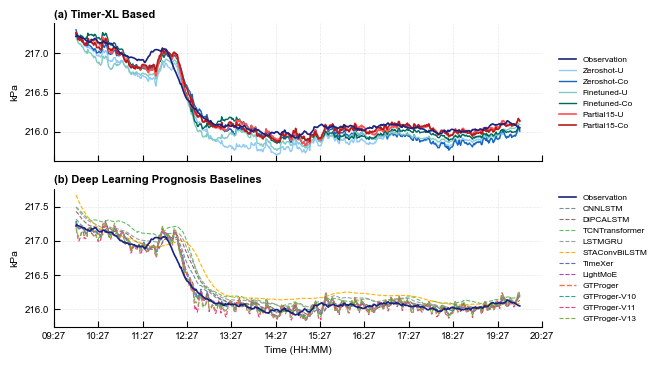

Saved a_dual_panel_range.png


In [93]:
# ========== Dual-panel: TSFM (top) vs MyTimeXer (bottom) ==========
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np, pandas as pd

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7.5, "axes.labelsize": 7.5, "axes.titlesize": 8,
    "axes.titleweight": "bold", "axes.linewidth": 0.8,
    "xtick.labelsize": 7, "ytick.labelsize": 7,
    "xtick.direction": "in", "ytick.direction": "in",
    "legend.fontsize": 6.5, "legend.frameon": False,
    "grid.linestyle": "--", "grid.linewidth": 0.5, "grid.alpha": 0.3,
    "pdf.fonttype": 42, "ps.fonttype": 42,
})

start_t = 111600; duration = 600; end_t = start_t + duration
x_vals = pd.date_range(start="2024-09-10 09:57:00", periods=duration + 1, freq="min")

obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

tsfm_models = [
    (pred_zeroshot_u,   "Zeroshot-U",   C_ZS_U,   '-',  1.0),
    (pred_zeroshot_co,  "Zeroshot-Co",  C_ZS_CO,  '-',  1.0),
    (pred_finetuned_u,  "Finetuned-U",  C_FT_U,   '-',  1.0),
    (pred_finetuned_co, "Finetuned-Co", C_FT_CO,  '-',  1.0),
    (pred_partial15_u,  "Partial15-U",  C_P15_U,  '-',  1.2),
    (pred_partial15_co, "Partial15-Co", C_P15_CO, '-',  1.2),
]
mtx_models = [
    (pred_cnnlstm,       "CNNLSTM",       C_CNNLSTM,       '--', 0.8),
    (pred_dipcalstm,     "DiPCALSTM",     C_DIPCALSTM,     '--', 0.8),
    (pred_tcn,           "TCNTransformer", C_TCN,           '--', 0.8),
    (pred_lstmgru,       "LSTMGRU",       C_LSTMGRU,       '--', 0.8),
    (pred_STAConvBiLSTM, "STAConvBiLSTM", C_STACONVBILSTM, '--', 0.8),
    (pred_timexer,       "TimeXer",       C_TIMEXER,       '--', 0.8),
    (pred_lightmoe,      "LightMoE",      C_LIGHTMOE,      '--', 0.8),
    (plot_pred_gtp,      "GTProger",      C_GTPROGER,      '--', 1.0),
    (pred_gtprogerv10,   "GTProger-V10",  C_V10,           '--', 0.8),
    (pred_gtprogerv11,   "GTProger-V11",  C_V11,           '--', 0.8),
    (pred_gtprogerv13,   "GTProger-V13",  C_V13,           '--', 0.8),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16/2.54, 10/2.54), sharex=True,
                                gridspec_kw={'hspace': 0.2})

for ax, group, title in [(ax1, tsfm_models, "(a) Timer-XL Based"),
                          (ax2, mtx_models,  "(b) Deep Learning Prognosis Baselines")]:
    ax.plot(x_vals, obs, label="Observation", linewidth=1.2, color="#1A237E", zorder=10)
    for data, label, color, ls, lw in group:
        sig = reconstruct_signal(data, start_t, end_t, pred_len=eval_steps)
        ax.plot(x_vals, sig, label=label, color=color, linestyle=ls, linewidth=lw, zorder=3)
    ax.set_title(title, loc='left', fontsize=8, fontweight='bold', pad=4)
    ax.set_ylabel("kPa", fontsize=7.5)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    
    # 修改图例位置到右侧
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=6,
              ncol=1, handlelength=2.0, frameon=False)
    
    ax.tick_params(axis='both', which='major', direction='in', length=4, width=0.8)

ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.set_xlabel("Time (HH:MM)", fontsize=7.5)

# 调整右侧边距为图例留出空间
plt.subplots_adjust(right=0.9)
plt.tight_layout()

fig.savefig("a_dual_panel_range.png", dpi=600, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved a_dual_panel_range.png")

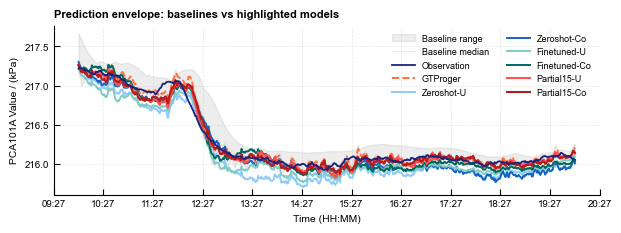

Saved a_envelope_highlight.png


In [99]:
# ========== Prediction envelope (baseline band) + highlighted models ==========
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np, pandas as pd

start_t = 111600; duration = 600; end_t = start_t + duration
x_vals = pd.date_range(start="2024-09-10 09:57:00", periods=duration + 1, freq="min")
obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

# Build envelope from all MyTimeXer baselines
baseline_arrs = [pred_cnnlstm, pred_dipcalstm, pred_tcn, pred_lstmgru,
                 pred_STAConvBiLSTM, pred_timexer, pred_lightmoe,
                 pred_gtprogerv10, pred_gtprogerv11, pred_gtprogerv13]
baseline_sigs = np.array([reconstruct_signal(a, start_t, end_t, pred_len=eval_steps)
                          for a in baseline_arrs])
env_lo = np.nanmin(baseline_sigs, axis=0)
env_hi = np.nanmax(baseline_sigs, axis=0)
env_med = np.nanmedian(baseline_sigs, axis=0)

# Highlighted models
highlight = [
    (plot_pred_gtp,    "GTProger",    C_GTPROGER,  '--', 1.4),
    (pred_zeroshot_u,   "Zeroshot-U",   C_ZS_U,   '-',  1.4),
    (pred_zeroshot_co,  "Zeroshot-Co",  C_ZS_CO,  '-',  1.4),
    (pred_finetuned_u,  "Finetuned-U",  C_FT_U,   '-',  1.4),
    (pred_finetuned_co, "Finetuned-Co", C_FT_CO,  '-',  1.4),
    (pred_partial15_u, "Partial15-U", C_P15_U,     '-',  1.5),
    (pred_partial15_co,"Partial15-Co",C_P15_CO,    '-',  1.5),
]

fig, ax = plt.subplots(figsize=(16/2.54, 6/2.54))
ax.fill_between(x_vals, env_lo, env_hi, alpha=0.18, color='#9E9E9E', label='Baseline range', zorder=1)
ax.plot(x_vals, env_med, color='#BDBDBD', linewidth=0.6, linestyle=':', label='Baseline median', zorder=2)
ax.plot(x_vals, obs, label="Observation", linewidth=1.3, color="#1A237E", zorder=10)

for data, label, color, ls, lw in highlight:
    sig = reconstruct_signal(data, start_t, end_t, pred_len=eval_steps)
    ax.plot(x_vals, sig, label=label, color=color, linestyle=ls, linewidth=lw, zorder=5)

ax.set_ylabel("PCA101A Value / (kPa)", fontsize=7.5)
ax.set_xlabel("Time (HH:MM)", fontsize=7.5)
ax.set_title("Prediction envelope: baselines vs highlighted models", loc='left',
             fontsize=8, fontweight='bold', pad=6)
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', ncol=2, fontsize=6.5, handlelength=2.5)
ax.tick_params(direction='in', length=4, width=0.8)
plt.tight_layout()
fig.savefig("a_envelope_highlight.png", dpi=600, facecolor='white')
plt.show()
print("Saved a_envelope_highlight.png")

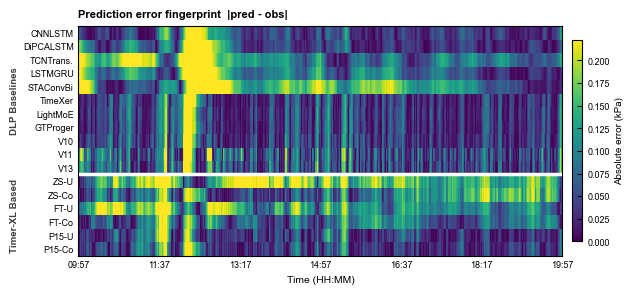

Saved a_error_heatmap.png


In [143]:
# ========== Error fingerprint heatmap ==========
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np, pandas as pd

start_t = 111600; duration = 600; end_t = start_t + duration
obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

all_models = [
    # MyTimeXer baselines
    (pred_cnnlstm,       "CNNLSTM"),
    (pred_dipcalstm,     "DiPCALSTM"),
    (pred_tcn,           "TCNTrans."),
    (pred_lstmgru,       "LSTMGRU"),
    (pred_STAConvBiLSTM, "STAConvBi"),
    (pred_timexer,       "TimeXer"),
    (pred_lightmoe,      "LightMoE"),
    (plot_pred_gtp,      "GTProger"),
    (pred_gtprogerv10,   "V10"),
    (pred_gtprogerv11,   "V11"),
    (pred_gtprogerv13,   "V13"),
    # TSFM
    (pred_zeroshot_u,    "ZS-U"),
    (pred_zeroshot_co,   "ZS-Co"),
    (pred_finetuned_u,   "FT-U"),
    (pred_finetuned_co,  "FT-Co"),
    (pred_partial15_u,   "P15-U"),
    (pred_partial15_co,  "P15-Co"),
]
n_models = len(all_models)

# Build error matrix: |pred - true| for each model at each time step
err_matrix = np.full((n_models, duration + 1), np.nan)
for i, (data, _) in enumerate(all_models):
    sig = reconstruct_signal(data, start_t, end_t, pred_len=eval_steps)
    err_matrix[i] = np.abs(sig - obs)

labels = [m[1] for m in all_models]

# Separate MyTimeXer and TSFM with a horizontal gap
fig, ax = plt.subplots(figsize=(16/2.54, 8/2.54))

# Robust color normalization (clip at 95th percentile)
vmax = np.nanpercentile(err_matrix, 95)
norm = mcolors.Normalize(vmin=0, vmax=vmax)

# Subsample for cleaner rendering (every 1 min is already 1 pixel)
im = ax.imshow(err_matrix, aspect='auto', cmap='viridis', norm=norm,
               interpolation='nearest', origin='upper')

# Draw group separator
ax.axhline(10.5, color='white', linewidth=2.5)
ax.text(-80, 5.0, 'DLP Baselines', fontsize=7, fontweight='bold', ha='center', va='center',
        rotation=90, color='#424242')
ax.text(-80, 13.5, 'Timer-XL Based', fontsize=7, fontweight='bold', ha='center', va='center',
        rotation=90, color='#424242')

ax.set_yticks(range(n_models))
ax.set_yticklabels(labels, fontsize=6.5)

# X-axis as time
n_ticks = 7
tick_pos = np.linspace(0, duration, n_ticks, dtype=int)
times = pd.date_range(start="2024-09-10 09:57:00", periods=duration + 1, freq="min")
ax.set_xticks(tick_pos)
ax.set_xticklabels([times[t].strftime("%H:%M") for t in tick_pos], fontsize=6.5)
ax.set_xlabel("Time (HH:MM)", fontsize=7.5)

ax.set_title("Prediction error fingerprint  |pred - obs|", loc='left',
             fontsize=8, fontweight='bold', pad=6)

cbar = fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02)
cbar.set_label("Absolute error (kPa)", fontsize=7)
cbar.ax.tick_params(labelsize=6.5)

ax.tick_params(axis='both', length=0)
plt.subplots_adjust(left=0.12, right=0.92, top=0.88, bottom=0.15)
fig.savefig("a_error_heatmap.png", dpi=600, facecolor='white')
plt.show()
print("Saved a_error_heatmap.png")

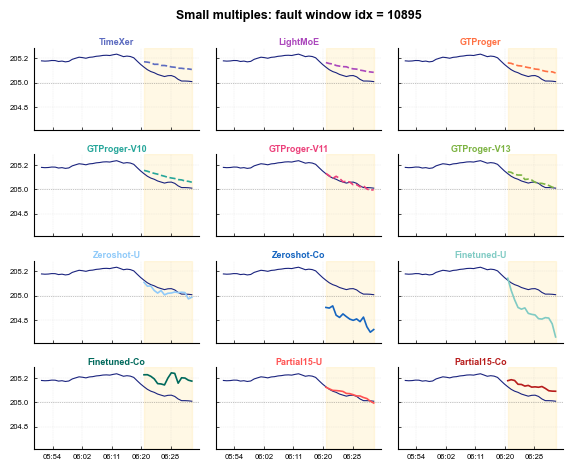

Saved a_small_multiples_fault.png


In [172]:
# ========== Small multiples: each model in its own panel ==========
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import numpy as np, pandas as pd

display_seq = 30; display_pred = eval_steps
idx = 10895
true_45 = build_true45_from_patches(plot_true, idx, seq_len=display_seq, pred_len=display_pred)
x_vals = pd.date_range(start="2024-11-02 05:51:00", periods=display_seq + display_pred, freq="min")

models_grid = [
    # (pred_cnnlstm,       "CNNLSTM",       C_CNNLSTM,       '--'),
    # (pred_dipcalstm,     "DiPCALSTM",     C_DIPCALSTM,     '--'),
    # (pred_tcn,           "TCNTransformer", C_TCN,           '--'),
    # (pred_lstmgru,       "LSTMGRU",       C_LSTMGRU,       '--'),
    # (pred_STAConvBiLSTM, "STAConvBiLSTM", C_STACONVBILSTM, '--'),
    (pred_timexer,       "TimeXer",       C_TIMEXER,       '--'),
    (pred_lightmoe,      "LightMoE",      C_LIGHTMOE,      '--'),
    (plot_pred_gtp,      "GTProger",      C_GTPROGER,      '--'),
    (pred_gtprogerv10,   "GTProger-V10",  C_V10,           '--'),
    (pred_gtprogerv11,   "GTProger-V11",  C_V11,           '--'),
    (pred_gtprogerv13,   "GTProger-V13",  C_V13,           '--'),
    (pred_zeroshot_u,    "Zeroshot-U",    C_ZS_U,          '-'),
    (pred_zeroshot_co,   "Zeroshot-Co",   C_ZS_CO,         '-'),
    (pred_finetuned_u,   "Finetuned-U",   C_FT_U,          '-'),
    (pred_finetuned_co,  "Finetuned-Co",  C_FT_CO,         '-'),
    (pred_partial15_u,   "Partial15-U",   C_P15_U,         '-'),
    (pred_partial15_co,  "Partial15-Co",  C_P15_CO,        '-'),
]

ncols = 3
nrows = int(np.ceil(len(models_grid) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16/2.54, 12/2.54),
                          sharex=True, sharey=True)
axes_flat = axes.flatten()

# Compute global y limits from all predictions
all_pred_vals = []
for data, *_ in models_grid:
    p45 = build_pred45_from_patch(data, idx, display_seq, display_pred)
    all_pred_vals.append(np.nanmin(p45[display_seq:]))
    all_pred_vals.append(np.nanmax(p45[display_seq:]))
all_pred_vals.extend([np.nanmin(true_45), np.nanmax(true_45)])
g_min, g_max = min(all_pred_vals), max(all_pred_vals)
g_pad = (g_max - g_min) * 0.08
g_ylim = (g_min - g_pad, g_max + g_pad)

for i, (data, label, color, ls) in enumerate(models_grid):
    ax = axes_flat[i]
    pred_45 = build_pred45_from_patch(data, idx, display_seq, display_pred)

    # Observation
    ax.plot(x_vals, true_45, color='#1A237E', linewidth=0.8, zorder=5)
    # Prediction
    ax.plot(x_vals, pred_45, color=color, linestyle=ls, linewidth=1.2, zorder=6)
    # Forecast zone shading
    ax.axvspan(x_vals[display_seq], x_vals[-1], alpha=0.10, color='#FFC107', zorder=0)
    # Alarm line
    ax.axhline(205, color='#262626', linewidth=0.5, linestyle=':', alpha=0.5)

    ax.set_title(label, fontsize=6.5, fontweight='bold', pad=2, color=color)
    ax.set_ylim(g_ylim)
    ax.tick_params(axis='both', labelsize=5.5, direction='in', length=2, width=0.5)
    ax.grid(True, linewidth=0.3, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    
# Hide unused axes
for j in range(len(models_grid), len(axes_flat)):
    axes_flat[j].set_visible(False)

fig.suptitle("Small multiples: fault window idx = {}".format(idx),
             fontsize=9, fontweight='bold', y=0.98)
plt.subplots_adjust(left=0.08, right=0.92, top=0.90, bottom=0.05, hspace=0.3, wspace=0.1)
fig.savefig("a_small_multiples_fault.png", dpi=600, facecolor='white')
plt.show()
print("Saved a_small_multiples_fault.png")

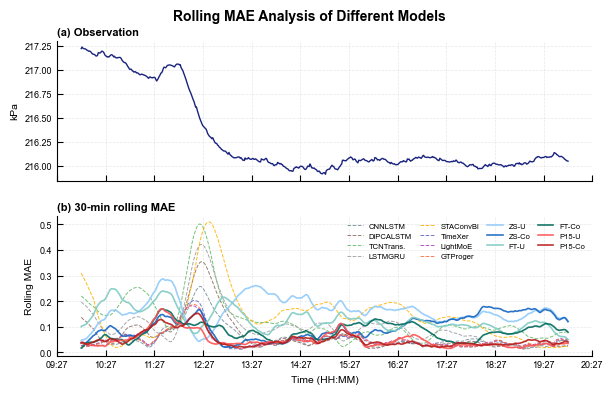

Saved a_rolling_mae.png


In [198]:
# ========== Rolling MAE ribbon chart ==========
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np, pandas as pd

start_t = 111600; duration = 600; end_t = start_t + duration
x_vals = pd.date_range(start="2024-09-10 09:57:00", periods=duration + 1, freq="min")
obs = reconstruct_signal(plot_true, start_t, end_t, pred_len=eval_steps)

models_mae = [
    (pred_cnnlstm,       "CNNLSTM",       C_CNNLSTM,       '--'),
    (pred_dipcalstm,     "DiPCALSTM",     C_DIPCALSTM,     '--'),
    (pred_tcn,           "TCNTrans.",      C_TCN,           '--'),
    (pred_lstmgru,       "LSTMGRU",       C_LSTMGRU,       '--'),
    (pred_STAConvBiLSTM, "STAConvBi",     C_STACONVBILSTM, '--'),
    (pred_timexer,       "TimeXer",       C_TIMEXER,       '--'),
    (pred_lightmoe,      "LightMoE",      C_LIGHTMOE,      '--'),
    (plot_pred_gtp,      "GTProger",      C_GTPROGER,      '--'),
    (pred_zeroshot_u,    "ZS-U",          C_ZS_U,          '-'),
    (pred_zeroshot_co,   "ZS-Co",         C_ZS_CO,         '-'),
    (pred_finetuned_u,   "FT-U",          C_FT_U,          '-'),
    (pred_finetuned_co,  "FT-Co",         C_FT_CO,         '-'),
    (pred_partial15_u,   "P15-U",         C_P15_U,         '-'),
    (pred_partial15_co,  "P15-Co",        C_P15_CO,        '-'),
]

window = 30  # 30-min rolling window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16/2.54, 10/2.54), sharex=True,
                                gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.25})

fig.suptitle("Rolling MAE Analysis of Different Models", fontsize=10, fontweight='bold', y=0.98)

# Top: original signal
ax1.plot(x_vals, obs, color='#1A237E', linewidth=1.0, label='Observation')
ax1.set_ylabel("kPa", fontsize=7.5)
ax1.set_title("(a) Observation", loc='left', fontsize=8, fontweight='bold', pad=4)
ax1.grid(True, linewidth=0.5, alpha=0.3, linestyle='--')
ax1.spines['top'].set_visible(False); ax1.spines['right'].set_visible(False)

# Bottom: rolling MAE for each model
for data, label, color, ls in models_mae:
    sig = reconstruct_signal(data, start_t, end_t, pred_len=eval_steps)
    abs_err = np.abs(sig - obs)
    # Rolling mean with nan handling
    roll = pd.Series(abs_err).rolling(window, min_periods=1, center=True).mean().values
    lw = 1.2 if ls == '-' else 0.7
    ax2.plot(x_vals, roll, color=color, linestyle=ls, linewidth=lw, label=label, alpha=0.9)

ax2.set_ylabel("Rolling MAE", fontsize=7.5)
ax2.set_xlabel("Time (HH:MM)", fontsize=7.5)
ax2.set_title("(b) {}-min rolling MAE".format(window), loc='left', fontsize=8, fontweight='bold', pad=4)
ax2.xaxis.set_major_locator(mdates.MinuteLocator(interval=60))
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
ax2.grid(True, linewidth=0.5, alpha=0.3, linestyle='--')
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)
ax2.legend(loc='upper right', ncol=4, fontsize=5.5, columnspacing=1.0, handlelength=2.0)

for ax in [ax1, ax2]:
    ax.tick_params(direction='in', length=4, width=0.8, labelsize=6.5)

plt.subplots_adjust(left=0.1, right=0.95, top=0.90, bottom=0.10)
fig.savefig("a_rolling_mae.png", dpi=600, facecolor='white')
plt.show()
print("Saved a_rolling_mae.png")